In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from wordcloud import WordCloud

import warnings
warnings.filterwarnings('ignore')

In [8]:
df = pd.read_csv(
    "dataset/spam.csv",
    sep=',',
    encoding='latin-1'
)

In [9]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [10]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [12]:
print(df.head())

print("\n")

print(df.columns)

print("\n")

print(df.shape)

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


(5572, 5)


In [13]:
df = pd.read_csv(
    "dataset/spam.csv",
    sep=',',
    encoding='latin-1'
)

print(df.columns)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [14]:
df = df.iloc[:, :2]

df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [15]:
print(df.columns)

Index(['label', 'message'], dtype='object')


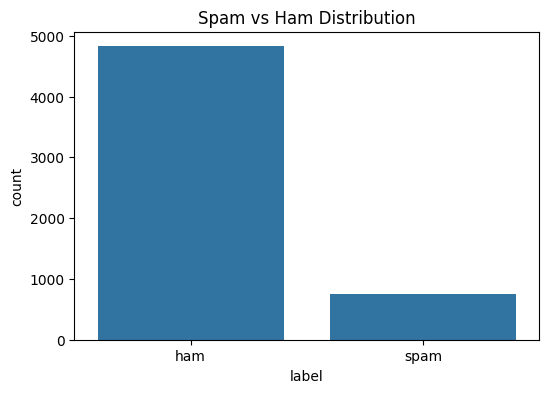

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='label',
    data=df
)

plt.title("Spam vs Ham Distribution")

plt.show()

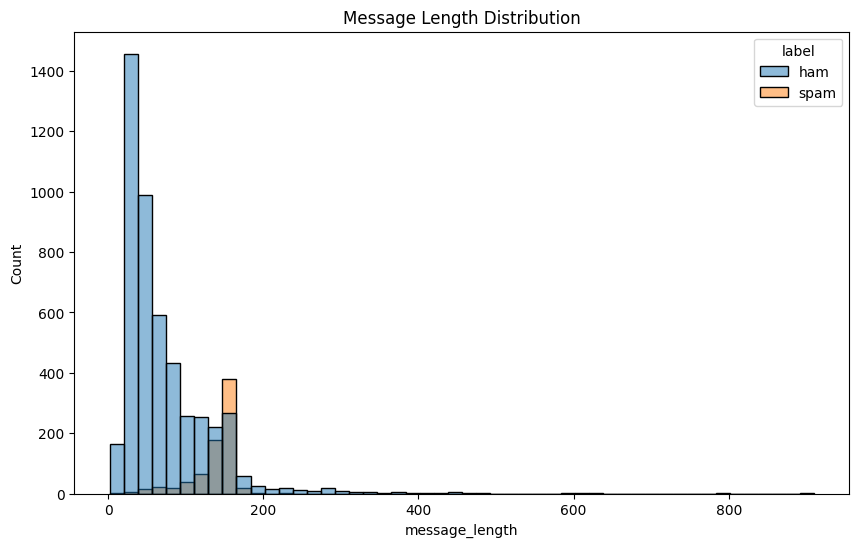

In [17]:
df['message_length'] = df['message'].apply(len)

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='message_length',
    hue='label',
    bins=50
)

plt.title("Message Length Distribution")

plt.show()

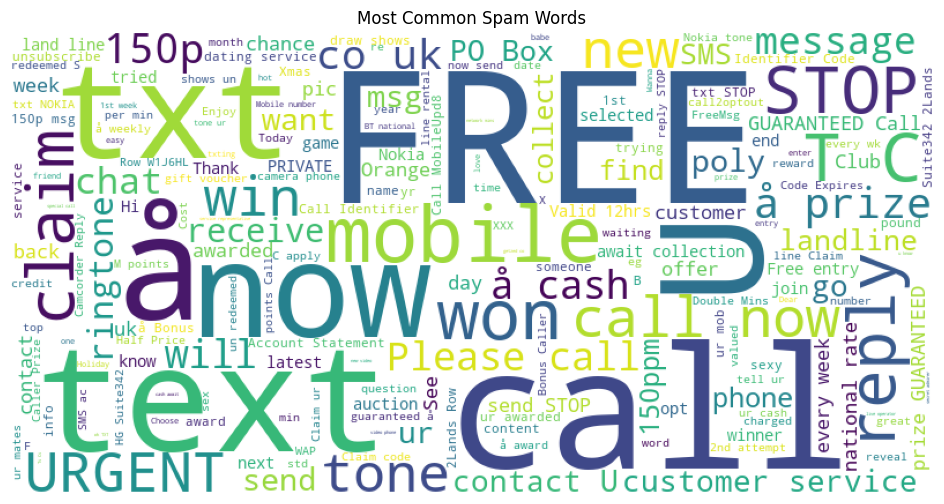

In [18]:
spam_words = ' '.join(
    list(df[df['label']=='spam']['message'])
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(spam_words)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Most Common Spam Words")

plt.show()

In [19]:
df['label_num'] = df['label'].map({
    'ham':0,
    'spam':1
})

df.head()

,label,message,message_length,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",111,0
1,ham,Ok lar... Joking wif u oni...,29,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,1
3,ham,U dun say so early hor... U c already then say...,49,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,0


In [20]:
X = df['message']

y = df['label_num']

In [21]:
vectorizer = CountVectorizer()

X_vectorized = vectorizer.fit_transform(X)

print(X_vectorized.shape)

(5572, 8672)


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.3,
    random_state=42
)

In [28]:
model = MultinomialNB()

model.fit(X_train, y_train)

print("Model Training Complete")

Model Training Complete


In [29]:
y_pred = model.predict(X_test)

y_pred[:10]

array([1, 0, 1, 0, 1, 0, 0, 0, 0, 0])

In [30]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.9784688995215312


In [26]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[952,  13],
       [ 11, 139]])

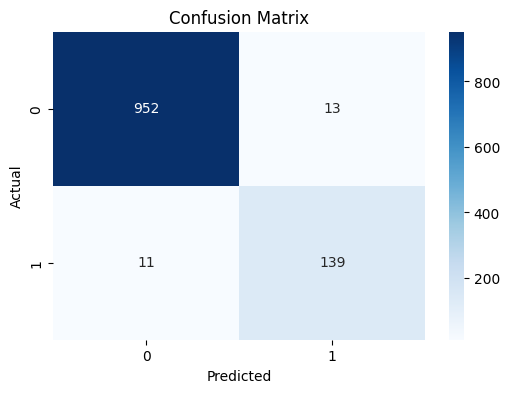

In [31]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [32]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1453
           1       0.92      0.92      0.92       219

    accuracy                           0.98      1672
   macro avg       0.95      0.95      0.95      1672
weighted avg       0.98      0.98      0.98      1672



In [ ]:
#CUSTOM MESSAGE PREDICTION
sample_message = [
    "Congratulations! You won a free iPhone"
]

sample_vector = vectorizer.transform(sample_message)

prediction = model.predict(sample_vector)

if prediction[0] == 1:
    print("SPAM MESSAGE")
else:
    print("HAM MESSAGE")

SPAM MESSAGE


In [34]:
#TRY YOUR OWN MESSAGE
msg = input("Enter Message: ")

msg_vector = vectorizer.transform([msg])

prediction = model.predict(msg_vector)

if prediction[0] == 1:
    print("\nSPAM MESSAGE")
else:
    print("\nHAM MESSAGE")


HAM MESSAGE
